# Clustering Evaluation

In [2]:
import pandas as pd
import json
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import numpy as np
import joblib
import matplotlib.pyplot as plt
# import ast
from collections import defaultdict
from kneed import KneeLocator

## Load and Parse Data

In [4]:
def json_to_dict(obj):
    return json.loads(obj)

def load_csv(path):
    df = pd.read_csv(path, dtype={'username':str})
    df['counts'] = df['counts'].map(json_to_dict)
    return df

In [5]:
df = load_csv(r'count_data\all_batches_sub_posts_count.csv')

In [6]:
df.shape

(218818, 2)

## Vectorizing

In [7]:
vec = DictVectorizer(sparse=True)

X_counts = vec.fit_transform(df['counts'].tolist())

X_counts.shape, X_counts.nnz

((218818, 132717), 2674332)

## Normalizing

In [8]:
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=True)

X_tfidf = tfidf.fit_transform(X_counts)

## Singular Value Decomposition

In [9]:
svd = TruncatedSVD(n_components=300, random_state=42)

X_reduced = svd.fit_transform(X_tfidf)

X_reduced.shape

(218818, 300)

## Elbow Method

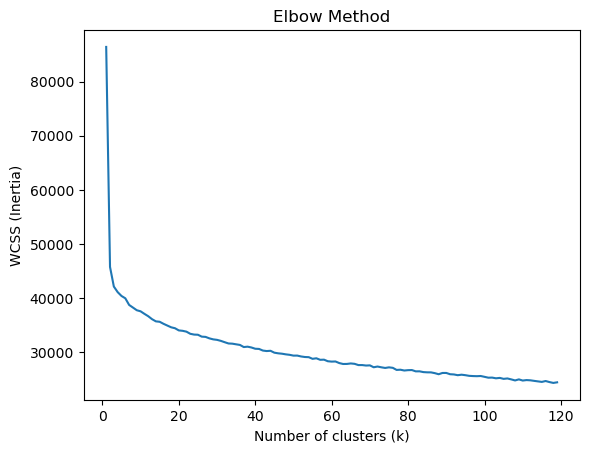

In [ ]:
wcss = []
for i in range(1, 120): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)


plt.plot(range(1, 120), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

Optimal number of clusters: 3


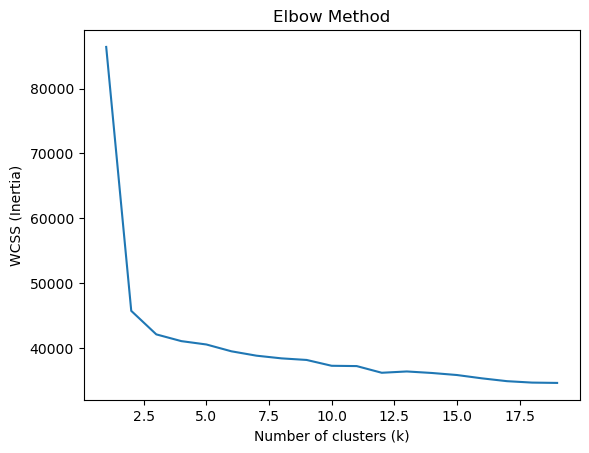

In [12]:
wcss = []
k_values = range(1, 20)
for i in k_values:
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10)
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)

kneedle = KneeLocator(
    k_values, wcss, 
    curve='convex', 
    direction='decreasing'
)

print(f'Optimal number of clusters: {kneedle.knee}')

plt.plot(k_values, wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

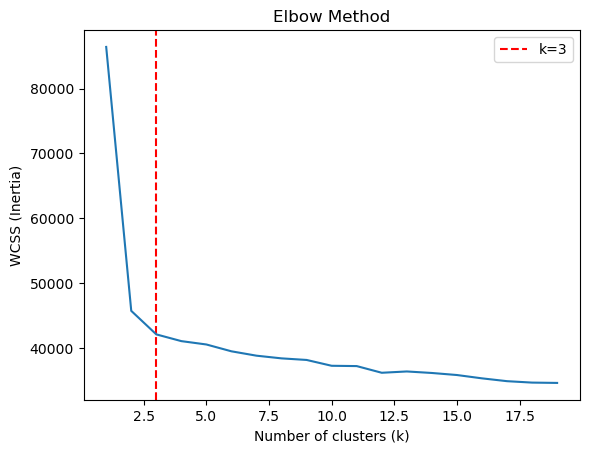

In [13]:
plt.axvline(kneedle.knee, color='r', linestyle='--', label=f"k={kneedle.knee}")
plt.plot(k_values, wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.show()

## Clustering

In [10]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    # batch_size=2000
)

labels=kmeans.fit_predict(X_reduced)
df['clusters'] = labels

In [ ]:
# k = 3

# kmeans = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=2000
# )

# labels=kmeans.fit_predict(X_reduced)
# df['clusters'] = labels

c:\Users\vince\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 6144 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


In [11]:
df.head()

,username,counts,clusters
0,---feelingalone---,{'SuicideWatch': 1},2
1,-anonymously,{'SuicideWatch': 1},2
2,-crave,"{'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...",1
3,-dogtopus-,"{'NoStupidQuestions': 1, 'TheGirlSurvivalGuide...",1
4,-ForPrivacy-,{'SuicideWatch': 1},2


In [12]:
df.groupby('clusters').size()

clusters
0      2919
1    148256
2     67643
dtype: int64

In [13]:
terms = vec.get_feature_names_out()

def top_subreddits_per_cluster(X_tfidf, labels, top_n=10):
    result = {}
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        mean_vec = X_tfidf[idx].mean(axis=0)       # sparse mean
        top_idx = np.asarray(mean_vec.A1).argsort()[-top_n:][::-1]
        result[c] = [terms[i] for i in top_idx]
    return result

cluster_tops = top_subreddits_per_cluster(X_tfidf, labels, top_n=10)
for c in sorted(cluster_tops):
    print(f"Cluster {c}: {', '.join(cluster_tops[c])}")


Cluster 0: AskReddit, SuicideWatch, depression, Advice, offmychest, Showerthoughts, relationship_advice, relationships, funny, NoStupidQuestions
Cluster 1: SuicideWatch, depression, AskReddit, offmychest, relationship_advice, Advice, selfharm, relationships, mentalhealth, teenagers
Cluster 2: SuicideWatch, depression, offmychest, selfharm, Advice, Anxiety, relationship_advice, lonely, mentalhealth, aww


**Get Counts for Each Cluster Subreddit**

## Avg. Cluster Counts

In [14]:
# df['counts'] = df['counts'].apply(json.loads)
clusters = df['clusters'].unique()

In [15]:
clusters

array([2, 1, 0])

In [17]:
for cluster in clusters:
    cluster_df = df[df['clusters'] == cluster]
    total_counts = defaultdict(int)
    for counts in cluster_df['counts']:
        for subreddit, count in counts.items():
            total_counts[subreddit] += count
    sorted_counts = dict(sorted(total_counts.items(), key=lambda item: item[1], reverse=True))
    print(f"Cluster {cluster}: {dict(list(sorted_counts.items())[:10])}")

Cluster 2: {'SuicideWatch': 81611, 'depression': 527, 'offmychest': 38, 'selfharm': 21, 'Advice': 19, 'Anxiety': 11, 'lonely': 11, 'relationship_advice': 10, 'mentalhealth': 6, 'aww': 5}
Cluster 1: {'AskReddit': 226971, 'SuicideWatch': 191815, 'depression': 96746, 'teenagers': 86600, 'NoStupidQuestions': 46525, 'memes': 38630, 'Showerthoughts': 34378, 'funny': 33747, 'aww': 29834, 'offmychest': 29661}
Cluster 0: {'AskReddit': 21849, 'SuicideWatch': 4005, 'depression': 987, 'Showerthoughts': 427, 'Advice': 401, 'NoStupidQuestions': 294, 'offmychest': 266, 'funny': 228, 'teenagers': 185, 'relationship_advice': 176}


In [16]:
for cluster in clusters:
    cluster_df = df[df['clusters'] == cluster]
    total_counts = defaultdict(int)
    for counts in cluster_df['counts']:
        for subreddit, count in counts.items():
            total_counts[subreddit] += count
    for subreddit in total_counts: #Average the counts
        total_counts[subreddit] = total_counts[subreddit] / len(cluster_df)
    sorted_counts = dict(sorted(total_counts.items(), key=lambda item: item[1], reverse=True))
    print(f"Cluster {cluster}: {dict(list(sorted_counts.items())[:15])}")

Cluster 2: {'SuicideWatch': 1.2064958680129503, 'depression': 0.0077909022367429, 'offmychest': 0.000561772836804991, 'selfharm': 0.00031045340981328447, 'Advice': 0.0002808864184024955, 'Anxiety': 0.00016261845275933947, 'lonely': 0.00016261845275933947, 'relationship_advice': 0.00014783495705394497, 'mentalhealth': 8.870097423236698e-05, 'aww': 7.391747852697249e-05, 'raisedbynarcissists': 7.391747852697249e-05, 'Vent': 7.391747852697249e-05, 'teenagers': 5.913398282157799e-05, 'rant': 4.435048711618349e-05, 'OCD': 4.435048711618349e-05}
Cluster 1: {'AskReddit': 1.5309397258795596, 'SuicideWatch': 1.2938093567882583, 'depression': 0.6525604360025901, 'teenagers': 0.5841247571767753, 'NoStupidQuestions': 0.31381529246708395, 'memes': 0.2605628102741204, 'Showerthoughts': 0.23188268940211526, 'funny': 0.22762653788042306, 'aww': 0.20123300237427152, 'offmychest': 0.20006610187783294, 'selfharm': 0.1889906647960285, 'pics': 0.18785074465788906, 'Advice': 0.18120683142672134, 'gaming': 0